<a href="https://colab.research.google.com/github/Habiba-gul/Twitter_Sentiment_Analysis_AI-ML-Project/blob/main/Twitter_Sentiment_Analysis_AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install -q wordcloud nltk scikit-learn matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [2]:
# Load Dataset
url = "https://raw.githubusercontent.com/sharmaroshan/Twitter-Sentiment-Analysis/master/train_tweet.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())


print("\nFirst 5 rows:")
display(df.head())


if 'label' in df.columns:
    print("\nSentiment labels found!")
    print(df['label'].value_counts())
else:
    print("\n⚠️ Warning: 'label' column not found in this file.")
    print("This version only has 'id' and 'tweet' columns.")
    print("We will switch to a better labeled dataset.")

    # 0 = Negative, 1 = Positive
    print("\nLoading alternative reliable dataset...")
    url2 = "https://raw.githubusercontent.com/dD1441/Twitter-Sentiment-Analysis/master/train.csv"
    df = pd.read_csv(url2)
    print("New dataset shape:", df.shape)
    print("New columns:", df.columns.tolist())
    display(df.head())

Dataset loaded successfully!
Dataset shape: (31962, 3)
Columns: ['id', 'label', 'tweet']

First 5 rows:


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation



Sentiment labels found!
label
0    29720
1     2242
Name: count, dtype: int64


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None

Sentiment Distribution:
label
0    29720
1     2242
Name: count, dtype: int64


/tmp/ipykernel_17432/1764318823.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette=['#FF6B6B', '#4ECDC4'])


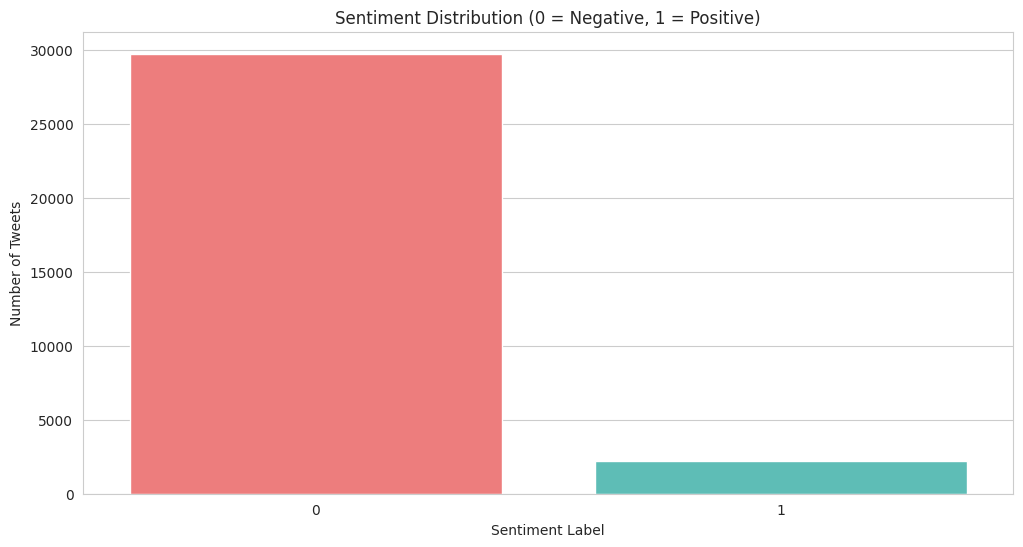

In [3]:
# Basic Info & Sentiment Distribution
print("Dataset Information:")
print(df.info())

print("\nSentiment Distribution:")
if 'label' in df.columns:
    print(df['label'].value_counts())


    sns.countplot(data=df, x='label', palette=['#FF6B6B', '#4ECDC4'])
    plt.title('Sentiment Distribution (0 = Negative, 1 = Positive)')
    plt.xlabel('Sentiment Label')
    plt.ylabel('Number of Tweets')
    plt.show()
else:
    print("No label column available for plotting.")

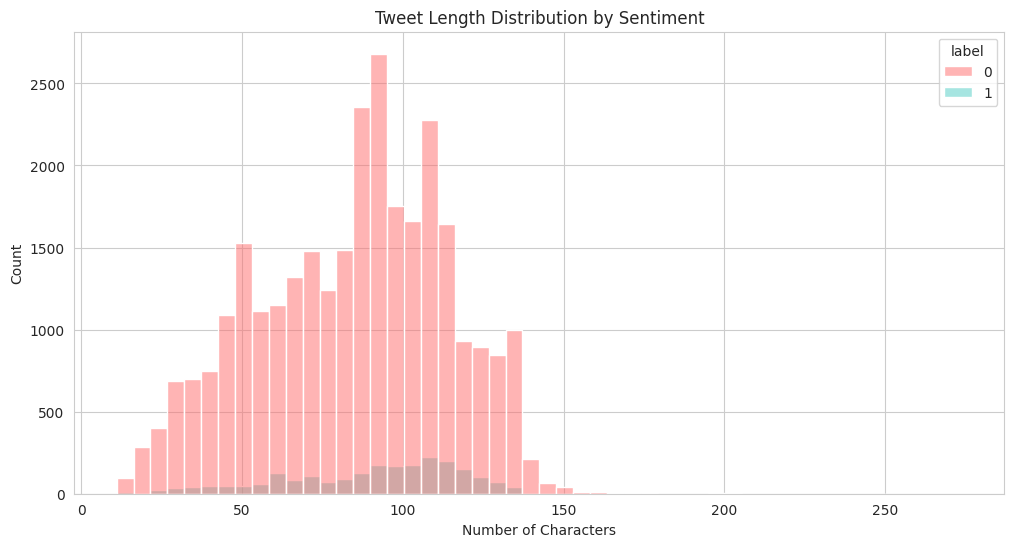

In [4]:
df['text_length'] = df['tweet'].apply(len)
sns.histplot(data=df, x='text_length', hue='label', bins=50, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Tweet Length Distribution by Sentiment')
plt.xlabel('Number of Characters')
plt.show()

In [5]:
# Data Cleaning & Preprocessing (Super Important!)

In [6]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')])


    stemmer = PorterStemmer()
    text = ' '.join([stemmer.stem(word) for word in text.split()])

    return text

print("Cleaning tweets... (this may take a minute)")
df['cleaned_tweet'] = df['tweet'].apply(clean_text)


print("Cleaning done!")
print("\nOriginal:", df['tweet'].iloc[0])
print("Cleaned :", df['cleaned_tweet'].iloc[0])

Cleaning tweets... (this may take a minute)
Cleaning done!

Original:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
Cleaned : father dysfunct selfish drag kid dysfunct


In [7]:
# Feature Extraction (TF-IDF)

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_tweet'])
y = df['label']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (31962, 5000)


In [9]:
# Train-Test Split + Model Training (Multiple Models!)

Training Logistic Regression...
Logistic Regression Accuracy: 0.9418

Training Naive Bayes...
Naive Bayes Accuracy: 0.9407

Training Linear SVC...
Linear SVC Accuracy: 0.9467



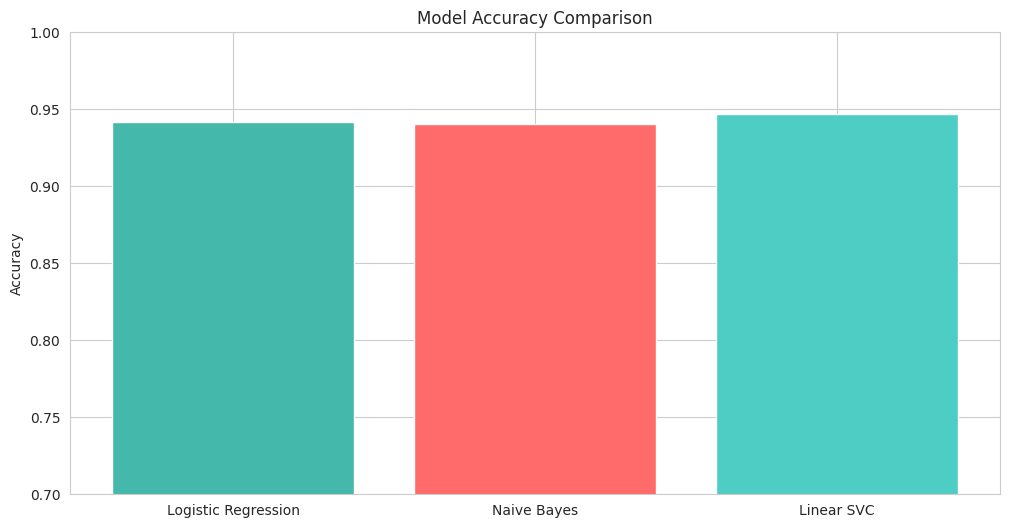

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(max_iter=1000)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}\n")


plt.bar(results.keys(), results.values(), color=['#45B8AC', '#FF6B6B', '#4ECDC4'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.show()

In [11]:
# Detailed Evaluation (Best Model)

Classification Report:

              precision    recall  f1-score   support

    Negative       0.94      1.00      0.97      5937
    Positive       0.86      0.22      0.35       456

    accuracy                           0.94      6393
   macro avg       0.90      0.61      0.66      6393
weighted avg       0.94      0.94      0.93      6393



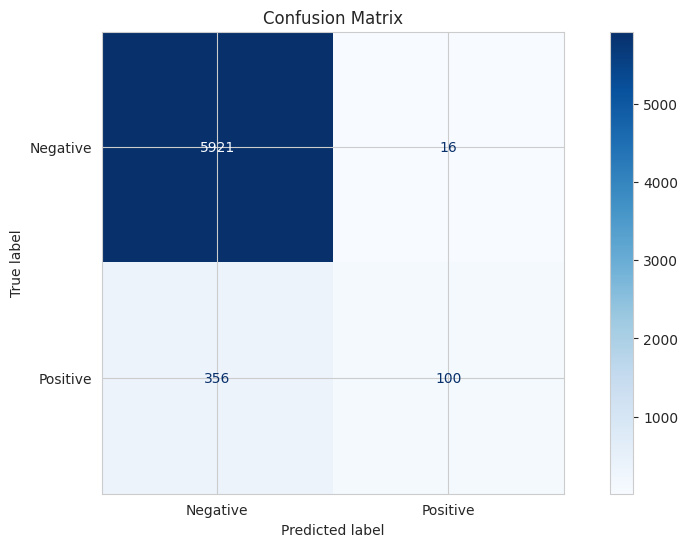

In [12]:

best_model = models["Logistic Regression"]
y_pred = best_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [13]:
# Beautiful Analysis - Word Clouds

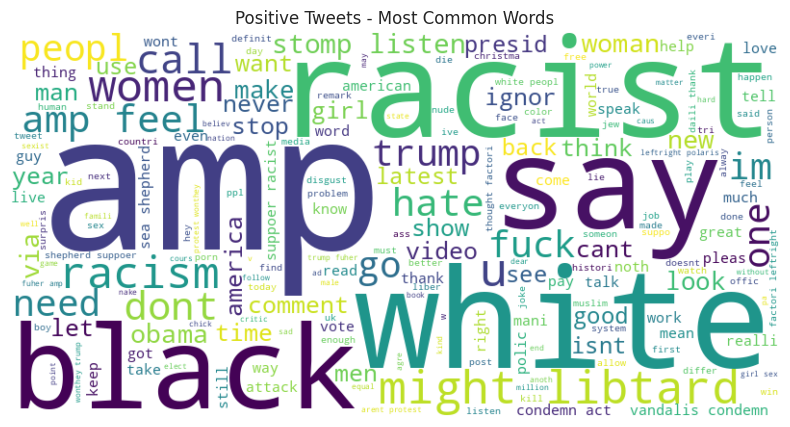

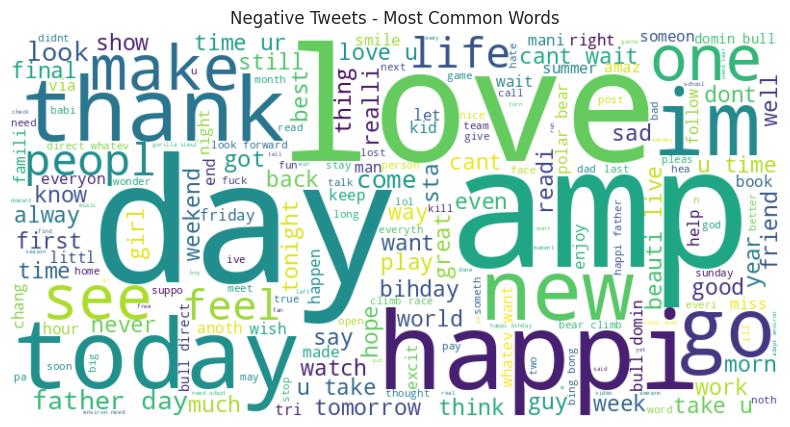

In [14]:
# Positive WordCloud
positive_tweets = ' '.join(df[df['label'] == 1]['cleaned_tweet'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_tweets)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Tweets - Most Common Words')
plt.show()

# Negative WordCloud
negative_tweets = ' '.join(df[df['label'] == 0]['cleaned_tweet'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_tweets)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Tweets - Most Common Words')
plt.show()

In [15]:
joblib.dump(best_model, 'twitter_sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print(" Model and vectorizer saved! You can load them later.")

 Model and vectorizer saved! You can load them later.


In [16]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Model Accuracy: 0.9418 (94.18%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      1.00      0.97      5937
    Positive       0.86      0.22      0.35       456

    accuracy                           0.94      6393
   macro avg       0.90      0.61      0.66      6393
weighted avg       0.94      0.94      0.93      6393

